In [681]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-prices-dataset/train.csv
/kaggle/input/car-prices-dataset/test.csv


In [682]:
df=pd.read_csv('/kaggle/input/car-prices-dataset/train.csv')

In [683]:
df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
13830,45625933,7213,915,BMW,X5,2014,Jeep,Yes,Diesel,3,0 km,6.0,Automatic,4x4,04-May,Left wheel,Black,0
3503,45431202,15994,475,CHEVROLET,Cruze,2012,Sedan,Yes,Petrol,1.4 Turbo,74000 km,4.0,Automatic,Front,04-May,Left wheel,Silver,8
17115,45801624,11604,586,TOYOTA,Prius,2012,Hatchback,Yes,Hybrid,1.8,0 km,4.0,Variator,Front,04-May,Left wheel,Black,10
7069,45753662,7840,-,OPEL,Astra,2001,Goods wagon,No,Petrol,1.6,0 km,4.0,Manual,Front,04-May,Left wheel,White,0
9239,45323998,36065,-,BMW,X5,2012,Jeep,Yes,Petrol,4.4 Turbo,186000 km,8.0,Tiptronic,4x4,04-May,Left wheel,Black,10


In [684]:
df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1543,45812964,251,584,HYUNDAI,Elantra,2014,Sedan,Yes,Petrol,1.8,40963 km,4.0,Automatic,Front,04-May,Left wheel,Blue,12
16983,45812886,26307500,-,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999 km,4.0,Manual,Front,02-Mar,Left wheel,Blue,0
10096,45590050,31361,-,MERCEDES-BENZ,Sprinter,2004,Microbus,Yes,Diesel,2.7 Turbo,200000 km,5.0,Manual,Rear,02-Mar,Left wheel,White,2
17083,45669452,18503,650,VOLKSWAGEN,Jetta,2016,Sedan,No,Petrol,1.4 Turbo,79000 km,4.0,Tiptronic,Front,04-May,Left wheel,White,6
18440,45772619,23521,1058,TOYOTA,Highlander,2012,Jeep,Yes,Petrol,3.5,140966 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12


In [685]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [686]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [687]:
from scipy import stats

In [688]:
df.drop(['ID'],axis=1,inplace=True)

In [689]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(include='object').columns

num_cols = num_cols.drop('Price')

In [690]:
num_cols

Index(['Prod. year', 'Cylinders', 'Airbags'], dtype='object')

In [691]:
cat_cols

Index(['Levy', 'Manufacturer', 'Model', 'Category', 'Leather interior',
       'Fuel type', 'Engine volume', 'Mileage', 'Gear box type',
       'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='object')

In [692]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [708]:
num_preprocessor=Pipeline(steps=[
    ('Scaling',StandardScaler()),
])

cat_preprocessor=Pipeline(steps=[
    ('ordinal_encoding', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

Here in the categorical columns if the value is ' - ' then it will handle it as -1 

In [709]:
preprocessor=ColumnTransformer(transformers=[
    ('numerical',num_preprocessor,num_cols),
    ('categorical',cat_preprocessor,cat_cols),
    
],remainder='passthrough',verbose_feature_names_out=True).set_output(transform="pandas")

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('Scaling',
                                                  StandardScaler())]),
                                 Index(['Prod. year', 'Cylinders', 'Airbags'], dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('ordinal_encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 Index(['Levy', 'Manufacturer', 'Model', 'Category', 'Leather interior',
       'Fuel type', 'Engine volume', 'Mileage', 'Gear box type',
       'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='object'))])

In [710]:
test=pd.read_csv('/kaggle/input/car-prices-dataset/test.csv')

In [711]:
x=df.drop(['Price'],axis=1)
y=df['Price']

In [712]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [713]:
x_train_p=preprocessor.fit_transform(x_train)
x_test_p=preprocessor.transform(x_test)

# Label encoder is only used for target features and for the trianing features ordinal encoder is used

In [714]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

In [715]:
x_train_p

,numerical__Prod. year,numerical__Cylinders,numerical__Airbags,categorical__Levy,categorical__Manufacturer,categorical__Model,categorical__Category,categorical__Leather interior,categorical__Fuel type,categorical__Engine volume,categorical__Mileage,categorical__Gear box type,categorical__Drive wheels,categorical__Doors,categorical__Wheel,categorical__Color
7808,0.364707,-0.485097,1.254361,443.0,57.0,384.0,9.0,1.0,2.0,45.0,2989.0,0.0,1.0,1.0,0.0,14.0
16766,-0.699707,-0.485097,-0.594687,73.0,8.0,404.0,4.0,1.0,1.0,35.0,5775.0,0.0,1.0,1.0,0.0,12.0
7285,-0.167500,1.188704,1.254361,105.0,35.0,534.0,9.0,1.0,1.0,62.0,2457.0,0.0,0.0,1.0,0.0,1.0
15712,0.187305,-0.485097,-0.594687,394.0,8.0,964.0,4.0,1.0,1.0,35.0,2908.0,0.0,1.0,1.0,0.0,7.0
16562,-1.941523,1.188704,-0.132425,0.0,5.0,1355.0,4.0,1.0,4.0,55.0,3265.0,2.0,0.0,1.0,0.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.251718,-0.485097,-0.594687,479.0,53.0,216.0,4.0,1.0,5.0,27.0,636.0,0.0,1.0,1.0,0.0,11.0
11964,1.251718,-0.485097,1.254361,381.0,57.0,384.0,9.0,1.0,2.0,45.0,4046.0,0.0,1.0,1.0,0.0,14.0
5390,0.542109,1.188704,-1.519210,486.0,5.0,1355.0,4.0,1.0,1.0,55.0,343.0,0.0,0.0,1.0,0.0,14.0
860,-1.054511,1.188704,1.254361,0.0,5.0,78.0,9.0,1.0,5.0,45.0,1877.0,2.0,2.0,1.0,1.0,14.0


In [716]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(16,)))
model.add(Dropout(0.2))
BatchNormalization()

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
BatchNormalization()

model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
BatchNormalization()

model.add(Dense(1,activation='linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [717]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

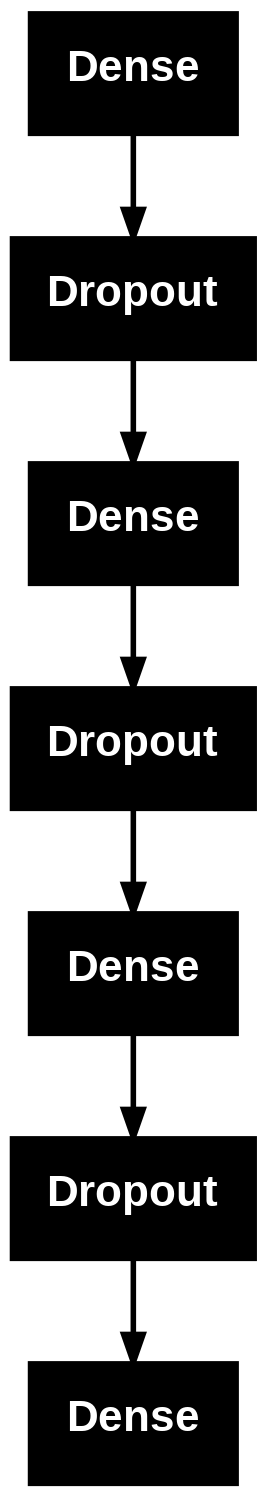

In [718]:
from keras.utils import plot_model
plot_model(model)

In [719]:
model.compile(optimizer='rmsprop',loss='mean_squared_error',metrics=['r2_score'])

In [720]:
history=model.fit(x_train_p,y_train,batch_size=64,epochs=25,validation_data=(x_test_p,y_test),verbose=1)

Epoch 1/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 29511391232.0000 - r2_score: -0.1934 - val_loss: 344241088.0000 - val_r2_score: -0.1048
Epoch 2/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 60907298816.0000 - r2_score: -0.0084 - val_loss: 328222656.0000 - val_r2_score: -0.0534
Epoch 3/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6547782144.0000 - r2_score: -0.0105 - val_loss: 321559136.0000 - val_r2_score: -0.0320
Epoch 4/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32741650432.0000 - r2_score: -0.0021 - val_loss: 316652640.0000 - val_r2_score: -0.0162
Epoch 5/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 106395516928.0000 - r2_score: 0.0039 - val_loss: 313148256.0000 - val_r2_score: -0.0050
Epoch 6/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54837510144.0000 - r2_score: 0.0050 - val_loss: 309809184.0000 - val_r2_score: 0.0057
Epoch 7/25
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3024517376.0000 - r2_score: 0.0145 - val_loss: 30702812

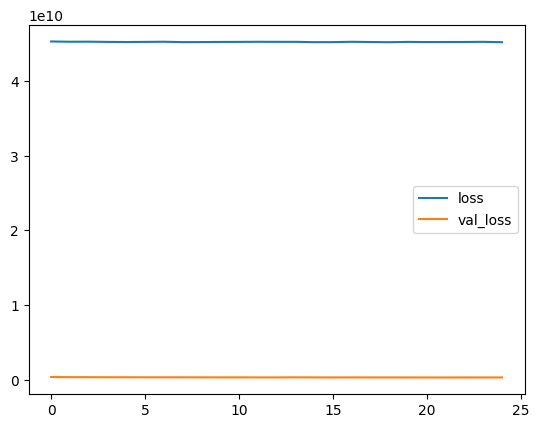

In [721]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()